In [1]:
!pip3 install segmentation-models-pytorch

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
from pathlib import Path
from PIL import Image
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.models.segmentation import fcn_resnet50
import torch.nn as nn
import segmentation_models_pytorch as smp
from tqdm import tqdm
import pandas as pd
import numpy as np
import time

from utils.lichen_dataset import LichenDataset


In [4]:
device = "cuda"

In [5]:
test_images = "/workspace/data_HITL/test/test_images"
test_masks = "/workspace/data_HITL/test/test_masks"

In [6]:
test_dataset = LichenDataset(
    image_dir=test_images,
    mask_dir=test_masks,
    image_size=512
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

Number of pairs found: 50


In [9]:
model = smp.DeepLabV3Plus(
    encoder_name="mobilenet_v2",
    encoder_weights=None,
    in_channels=3,
    classes=1
)

weights_path = "/workspace/weights_HITL/2deeplab_mobilenetv2_lichen.pth"

state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

DeepLabV3Plus(
  (encoder): MobileNetV2Encoder(
    (features): Sequential(
      (0): ConvBNActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): ConvBNActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): ConvBNActivation(
            (0): Conv2d(16, 96, kernel_size=(1, 1

In [10]:
def compute_metrics(pred, mask, eps=1e-7):
    pred = pred.bool()
    mask = mask.bool()

    tp = (pred & mask).sum().item()
    fp = (pred & ~mask).sum().item()
    fn = (~pred & mask).sum().item()
    tn = (~pred & ~mask).sum().item()

    iou = tp / (tp + fp + fn + eps)
    dice = (2 * tp) / (2 * tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    accuracy = (tp + tn) / (tp + tn + fp + fn + eps)

    return {
        "iou": iou,
        "dice": dice,
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy
    }

In [11]:
all_metrics = []
latencies = []

threshold = 0.5

with torch.no_grad():
    for images, masks, names in test_loader:
        images = images.to(device)
        masks = masks.to(device)

        if device == "cuda":
            torch.cuda.synchronize()

        start = time.time()

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = probs > threshold

        if device == "cuda":
            torch.cuda.synchronize()

        end = time.time()

        latency = end - start
        latencies.append(latency)

        metrics = compute_metrics(preds.cpu(), masks.cpu())
        metrics["filename"] = names[0]
        metrics["latency_sec"] = latency

        all_metrics.append(metrics)

In [12]:
df = pd.DataFrame(all_metrics)
df.head()

,iou,dice,precision,recall,accuracy,filename,latency_sec
0,0.658534,0.794116,0.670990,0.972583,0.841702,lichen_11032703,44.846890
1,0.543319,0.704091,0.873079,0.589912,0.703426,lichen_297012592,3.397843
2,0.842290,0.914395,0.876682,0.955498,0.859295,lichen_265585502,0.684270
3,0.176233,0.299656,0.228206,0.436241,0.832798,lichen_74735136,0.381840
4,0.587323,0.740017,0.973856,0.596732,0.831268,lichen_181096723,0.302809


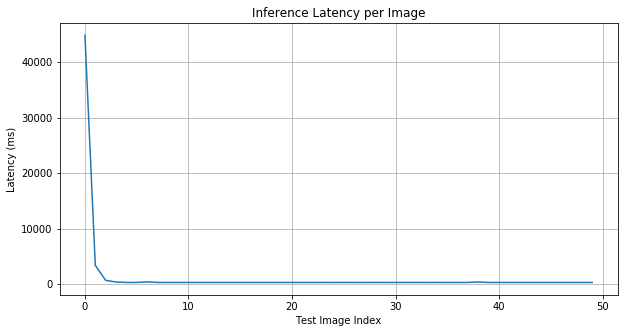

In [13]:
latencies_ms = [x * 1000 for x in latencies]

plt.figure(figsize=(10,5))

plt.plot(latencies_ms)

plt.xlabel("Test Image Index")
plt.ylabel("Latency (ms)")
plt.title("Inference Latency per Image")

plt.grid(True)

plt.show()

In [14]:
df.mean(numeric_only=True)

iou            0.568743
dice           0.694577
precision      0.762333
recall         0.720324
accuracy       0.844234
latency_sec    1.268815
dtype: float64

In [15]:
df

,iou,dice,precision,recall,accuracy,filename,latency_sec
0,0.658534,0.794116,0.670990,0.972583,0.841702,lichen_11032703,44.846890
1,0.543319,0.704091,0.873079,0.589912,0.703426,lichen_297012592,3.397843
2,0.842290,0.914395,0.876682,0.955498,0.859295,lichen_265585502,0.684270
3,0.176233,0.299656,0.228206,0.436241,0.832798,lichen_74735136,0.381840
4,0.587323,0.740017,0.973856,0.596732,0.831268,lichen_181096723,0.302809
5,0.385019,0.555977,0.651851,0.484689,0.872215,lichen_41813255,0.302536
6,0.874426,0.933007,0.913793,0.953046,0.955223,lichen_141767571,0.411248
7,0.298214,0.459422,0.832044,0.317316,0.642712,lichen_34608861,0.302558
8,0.602561,0.751997,0.652578,0.887154,0.861931,lichen_93036882,0.302551
9,0.863772,0.926907,0.905965,0.948840,0.920956,lichen_37456823,0.302640
